In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import multiprocessing
import os
import pickle
import logging

from functools import partial

logging.getLogger("pint").setLevel(logging.ERROR)

if os.environ.get("SLURM_CPUS_PER_TASK"):
    cores = int(os.environ.get("SLURM_CPUS_PER_TASK", 1))
else:
    cores = multiprocessing.cpu_count()
print(f"Number of cores: {cores}")

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count={}".format(cores)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table
from gpjax.kernels import RBF, Linear, Matern12, Matern32, Matern52, Periodic, White
from jax import jit
from jaxoplanet import orbits
from jaxoplanet.light_curves import LimbDarkLightCurve
from jaxopt import ScipyMinimize
from tensorflow_probability.substrates.jax.distributions import Normal
from tqdm import tqdm

from gallifrey.inference import predictive_distribution, log_likelihood_function
from gallifrey.kernelsearch import (
    KernelSearch,
    get_trainables,
    kernel_summary,
    set_trainables,
)
from gallifrey.mcmc import nuts_warmup, run_mcmc

Number of cores: 8


In [35]:
jax.config.update("jax_enable_x64", True)
rng_key = jax.random.PRNGKey(42)

mode = "load"

## LOAD DATA

In [36]:
model_name = "hats46b_gpmodel"

df = (
    Table.read("../data/external/HATS_46b.fit")
    .to_pandas()
    .drop(columns=["FWB20", "e_FWB20"])  # not used in paper
)

t = df["Time"].to_numpy()
t_min = np.amin(t)
t -= t_min

# spectroscopic and white light curves, initial entry is white lc
y = df.iloc[:, 1::2].to_numpy().T
yerr = df.iloc[:, 2::2].to_numpy().T

# mask out transit
mask = np.ones_like(t, dtype=bool)
mask[7:41] = False

# reference parameter and limb darkening parameter, first entry is white lc
reference = pd.read_csv("../data/external/HATS_46b_reference.csv").set_index(
    df.columns[1::2]
)

num_datasets = len(y)

## INDIVIDUAL KERNEL SEARCH FOR EVERY LIGHT CURVE

In [37]:
kernel_library = [
    Linear(),
    RBF(),
    Periodic(),
    White(),
    Matern12(),
    Matern32(),
    Matern52(),
]

In [38]:
gps = []
for i in range(num_datasets):
    if mode == "load":
        with open(
            f"../data/processed/observational_data/gp_models/hats46b/{model_name}_{i}",
            "rb",
        ) as file:
            gps.append(pickle.load(file))

    else:
        tree = KernelSearch(
            kernel_library,
            X=jnp.array(t[mask]),
            y=jnp.array(y[i][mask]),
            obs_stddev=jnp.amax(yerr[i][mask]),
            verbosity=0,
            criterion="aic",
        )

        model = tree.search(
            depth=7,
            n_leafs=2,
            patience=0,
        ).posterior
        gps.append(model)
        print(f"Dataset {i}: {kernel_summary(model, short=True)}")

        if mode == "save":
            with open(
                f"../data/processed/observational_data/gp_models/hats46b/{model_name}_{i}",
                "wb",
            ) as file:
                pickle.dump(gps[i], file)

## DEFINE TRANSIT MODEL

In [39]:
def transit_model(
    t, transit_parameter, period=4.7423749, u2=None, global_transit_parameter=None
):
    globals_flag = False if global_transit_parameter is None else True

    if globals_flag:
        scaled_radius = transit_parameter[0]
        limb_darkening_coeff = [transit_parameter[1], u2]
        central_mass = global_transit_parameter[0]
        central_radius = global_transit_parameter[1]
        inclination = jnp.deg2rad(global_transit_parameter[2])
        time_transit = global_transit_parameter[3]
    else:
        scaled_radius = transit_parameter[0]
        limb_darkening_coeff = [transit_parameter[1], u2]
        central_mass = transit_parameter[2]
        central_radius = transit_parameter[3]
        inclination = jnp.deg2rad(transit_parameter[4])
        time_transit = transit_parameter[5]

    central = orbits.keplerian.Central(
        mass=central_mass,
        radius=central_radius,
    )

    orbit = orbits.keplerian.Body(
        central=central,
        period=period,
        radius=scaled_radius * central.radius,
        inclination=inclination,
        time_transit=time_transit,
    )

    lc = LimbDarkLightCurve(limb_darkening_coeff).light_curve(orbit, t=t)
    return lc

## FIT TRANSIT PARAMETER FOR WHITE LC

In [40]:
white_lc_log_likelihood = log_likelihood_function(
    gps[0],
    jit(partial(transit_model, u2=reference["u2"]["FWL"])),
    t,
    y[0],
    mask,
    fix_gp=False,
    compile=True,
    negative=True,
)
x0 = {
    "gp_parameter": get_trainables(gps[0], unconstrain=True),
    # planet radius, u1, host_star_mass, host_star_radius, inclination, time_transit
    "lc_parameter": jnp.array([0.09773, 0.547, 0.869, 0.894, 86.97, 0.075]),
}
white_lc_solve = ScipyMinimize(fun=white_lc_log_likelihood, method="l-bfgs-b").run(x0)
white_lc_parameter = white_lc_solve.params["lc_parameter"]

In [41]:
white_lc_parameter

Array([1.15239247e-01, 4.38686367e-01, 8.80390246e-01, 8.60184639e-01,
       8.71308099e+01, 7.13317247e-02], dtype=float64)

## DEFINE LIKELIHOOD, PRIOR, POSTERIOR

In [45]:
def get_logprob(gp_model, y, u1, u2, initial_position=None, fix_gp=False):
    if initial_position is None:
        initial_position = {
            "gp_parameter": get_trainables(gp_model, unconstrain=True),
            "lc_parameter": jnp.array([0.12, u1]),
        }

    param_priors = {
        "gp_parameter": Normal(
            loc=initial_position["gp_parameter"],
            scale=0.2 * jnp.abs(initial_position["gp_parameter"]),
        ),
        "lc_parameter": Normal(
            loc=initial_position["lc_parameter"],
            scale=[0.2, 0.05],
        ),
    }

    # define light curve model
    lc_model = jit(
        partial(
            transit_model,
            u2=u2,
            global_transit_parameter=white_lc_parameter[2:],
        )
    )

    log_likelihood = log_likelihood_function(
        gp_model,
        lc_model,
        t,
        y,
        mask,
        fix_gp=fix_gp,
        compile=True,
    )

    @jit
    def log_priors(params):
        gp_log_priors = param_priors["gp_parameter"].log_prob(params["gp_parameter"])
        lc_log_priors = param_priors["lc_parameter"].log_prob(params["lc_parameter"])
        return jnp.sum(gp_log_priors) + jnp.sum(lc_log_priors)

    @jit
    def log_probability(params):
        return log_likelihood(params) + log_priors(params)

    return log_probability, initial_position

## PERFORM FITS

In [46]:
parameter_solutions = []
for i in tqdm(range(num_datasets)):
    # jax.clear_backends()
    # jax.clear_caches()
    log_probability, initial_position = get_logprob(
        gps[i],
        y[i],
        reference["u1"].iloc[i],
        reference["u2"].iloc[i],
    )
    solve = ScipyMinimize(
        fun=jit(lambda par: -log_probability(par)),
        method="l-bfgs-b",
    ).run(initial_position)
    parameter_solutions.append(solve.params)

  0%|          | 0/26 [00:00<?, ?it/s]

  4%|▍         | 1/26 [00:02<01:01,  2.48s/it]

{'gp_parameter': Array([ 1.29210389e+03, -9.21731571e-01,  5.40142903e-01], dtype=float64), 'lc_parameter': Array([0.11525537, 0.51294875], dtype=float64)}


  8%|▊         | 2/26 [00:04<00:54,  2.29s/it]

{'gp_parameter': Array([ 6.01251159e+02, -1.63142361e+00,  5.38330938e-01, -9.56557245e+00],      dtype=float64), 'lc_parameter': Array([0.11595751, 0.86832365], dtype=float64)}


...

{'gp_parameter': Array([4.49866000e+05, 5.41610229e-01], dtype=float64), 'lc_parameter': Array([0.1141971 , 0.52786522], dtype=float64)}


 38%|███▊      | 10/26 [00:21<00:34,  2.19s/it]

{'gp_parameter': Array([6.14765938e+05, 5.41874524e-01], dtype=float64), 'lc_parameter': Array([0.11622436, 0.56450169], dtype=float64)}


 38%|███▊      | 10/26 [00:23<00:38,  2.39s/it]


KeyboardInterrupt: 

## RUN MCMC

In [11]:
num_adapt = 200
num_samples = 100
num_chains = cores

fix_gp = False

In [12]:
chains = {"gp_parameter": [], "lc_parameter": []}

for i in tqdm(range(num_datasets)):
    if mode == "load":
        chain = np.load(
            f"../data/processed/observational_data/mcmc_chains/{model_name}_{i}_parameter.npz",
        )
        chains["gp_parameter"].append(chain["gp_parameter"])
        chains["lc_parameter"].append(chain["lc_parameter"])

    else:
        log_probability, initial_position = get_logprob(
            gps[i],
            y[i],
            reference["u1"].iloc[i],
            reference["u2"].iloc[i],
            initial_position=parameter_solutions[i],
            fix_gp=fix_gp,
        )

        # run nuts adaption
        rng_key, warmup_key = jax.random.split(rng_key, 2)
        state, parameters = nuts_warmup(
            warmup_key,
            log_probability,
            initial_position,
            num_steps=num_adapt,
            progress_bar=False,
        )

        # define initial positions and add scatter
        initial_positions = {}
        for key, value in initial_position.items():
            rng_key, scatter_key = jax.random.split(rng_key)
            initial_positions[key] = jnp.tile(
                value, (num_chains, 1)
            ) + 0.05 * value * jax.random.normal(
                scatter_key, shape=(num_chains, value.size)
            )

        rng_key, sample_key = jax.random.split(rng_key, 2)

        final_state, state_history, info_history = run_mcmc(
            sample_key,
            log_probability,
            parameters,
            initial_positions,
            num_steps=num_samples,
        )

        for par in ["gp_parameter", "lc_parameter"]:
            chain = np.array(state_history.position[par])
            chains[par].append(chain)

        if mode == "save":
            np.savez(
                f"../data/processed/observational_data/mcmc_chains/{model_name}_{i}_parameter.npz",
                **{key: chains[key][i] for key in chains.keys()},
            )

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:00<00:00, 1403.75it/s]


## Analysis

In [15]:
Rp_percentiles = np.percentile(
    np.array(chains["lc_parameter"]).reshape(26, num_samples * num_chains, 2),
    [50, 16, 84],
    axis=1,
)[:, :, 0]

In [22]:
np.array(chains["lc_parameter"]).reshape(26, num_samples * num_chains, 2).shape

(26, 800, 2)

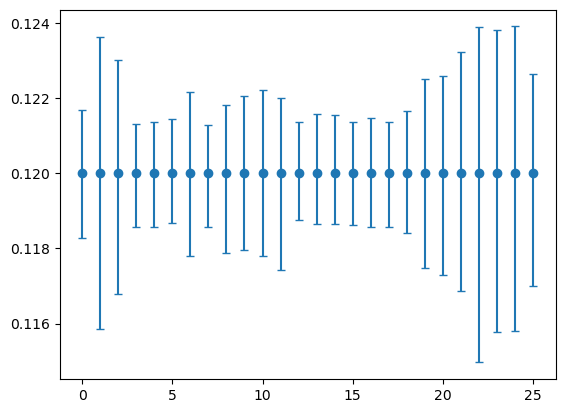

In [28]:
plt.errorbar(
    range(num_datasets),
    np.array([sol["lc_parameter"][0] for sol in parameter_solutions]),
    yerr=np.array(
        [Rp_percentiles[0] - Rp_percentiles[1], Rp_percentiles[2] - Rp_percentiles[0]]
    ),
    fmt=".",
    capsize=3,
)
plt.scatter(range(num_datasets), [p["lc_parameter"][0] for p in parameter_solutions])

# plt.errorbar(
#     range(num_datasets),
#     reference["Rp"],
#     yerr=reference[["e_Rp_lower", "e_Rp_upper"]].T,
#     fmt=".",
#     capsize=3,
# )

In [32]:
[p["lc_parameter"][0] for p in parameter_solutions]

[Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64),
 Array(0.12, dtype=float64)]